## **Imports**


In [1]:
import os
import time
import random
import glob
import shutil
import xml.etree.ElementTree as ET

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import yaml

import torch
import torchvision
import torchvision.models as models
import torchvision.transforms as T
from torchvision.ops import roi_pool

print(f"PyTorch     : {torch.__version__}")
print(f"Torchvision : {torchvision.__version__}")
print(f"OpenCV      : {cv2.__version__}")
print(f"CUDA        : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
    print(f"VRAM        : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using       : {DEVICE}")

PyTorch     : 2.7.1+cu118
Torchvision : 0.22.1+cu118
OpenCV      : 4.9.0
CUDA        : True
GPU         : NVIDIA GeForce GTX 1650 Ti
VRAM        : 4.3 GB
Using       : cuda


## **Dataset Paths**

In [8]:
THIS_DIR   = os.path.dirname(os.path.abspath('__file__'))
TRAIN_DIR  = os.path.join(THIS_DIR, 'data', 'train_zip', 'train')
TEST_DIR   = os.path.join(THIS_DIR, 'data', 'test_zip',  'test')

CLASS_NAMES  = ['apple', 'banana', 'orange']   # index 0, 1, 2
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
CLASS_COLORS = {'apple': (220, 50, 50), 'banana': (230, 200, 30), 'orange': (240, 140, 30)}

print(f"\nClass map : {CLASS_TO_IDX}")


Class map : {'apple': 0, 'banana': 1, 'orange': 2}


## **Preparation - Ground Truth Visualization**

### **XML Parser**

In [9]:
def parse_voc_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size = root.find('size')
    img_w = int(size.find('width').text)
    img_h = int(size.find('height').text)

    boxes = []
    for obj in root.findall('object'):
        name_tag = obj.find('n')
        if name_tag is None:
            name_tag = obj.find('name')
        if name_tag is None:
            continue
        class_name = name_tag.text.strip().lower()

        bndbox = obj.find('bndbox')
        xmin = int(float(bndbox.find('xmin').text))
        ymin = int(float(bndbox.find('ymin').text))
        xmax = int(float(bndbox.find('xmax').text))
        ymax = int(float(bndbox.find('ymax').text))

        xmin = max(0, min(xmin, img_w - 1))
        ymin = max(0, min(ymin, img_h - 1))
        xmax = max(0, min(xmax, img_w))
        ymax = max(0, min(ymax, img_h))

        boxes.append({
            'class_name': class_name,
            'class_id'  : CLASS_TO_IDX.get(class_name, -1),
            'xmin': xmin, 'ymin': ymin,
            'xmax': xmax, 'ymax': ymax
        })
    return boxes, img_w, img_h


def draw_boxes_on_image(img_bgr, boxes, title='Ground Truth'):
    img_rgb = cv2.cvtColor(img_bgr.copy(), cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(img_rgb)
    for b in boxes:
        color = [c / 255 for c in CLASS_COLORS.get(b['class_name'], (180, 180, 180))]
        w = b['xmax'] - b['xmin']
        h = b['ymax'] - b['ymin']
        rect = patches.Rectangle((b['xmin'], b['ymin']), w, h,
                                   linewidth=2.5, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(b['xmin'], b['ymin'] - 6, b['class_name'].capitalize(),
                color='white', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.25', facecolor='black', alpha=0.6))
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

### **Visualise Bounding Box**

Total training images : 240
Selected image        : mixed_5.jpg
Image size            : 1024 x 1024
Ground truth objects  : 3
  orange    [556, 178, 950, 559]
  apple     [ 73, 164, 474, 550]
  banana    [177, 604, 858, 966]


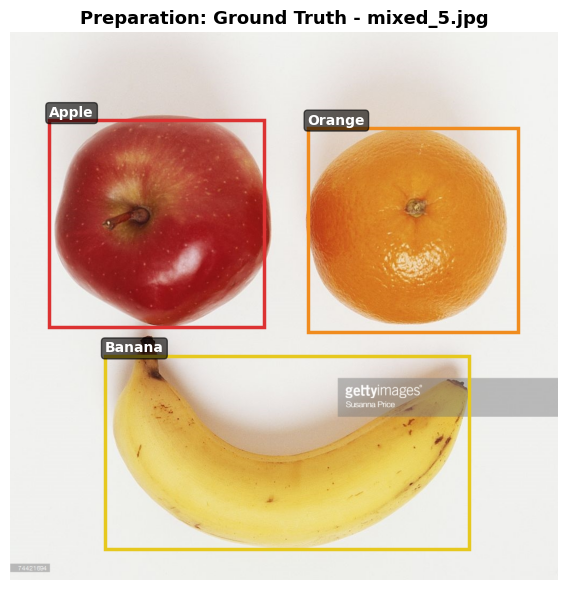

In [10]:
random.seed(42)
all_train_imgs = sorted(glob.glob(os.path.join(TRAIN_DIR, '*.jpg')))
print(f"Total training images : {len(all_train_imgs)}")

SAMPLE_IMG_PATH = random.choice(all_train_imgs)
SAMPLE_XML_PATH = SAMPLE_IMG_PATH.replace('.jpg', '.xml')
print(f"Selected image        : {os.path.basename(SAMPLE_IMG_PATH)}")

sample_img  = cv2.imread(SAMPLE_IMG_PATH)
gt_boxes, W, H = parse_voc_xml(SAMPLE_XML_PATH)

print(f"Image size            : {W} x {H}")
print(f"Ground truth objects  : {len(gt_boxes)}")
for b in gt_boxes:
    print(f"  {b['class_name']:8s}  [{b['xmin']:3d}, {b['ymin']:3d}, {b['xmax']:3d}, {b['ymax']:3d}]")

draw_boxes_on_image(sample_img, gt_boxes,
                    title=f"Preparation: Ground Truth - {os.path.basename(SAMPLE_IMG_PATH)}")

## **Task 1: Intersection over Union (IoU)**

### **IoU from scratch**

In [11]:
def compute_iou(box1, box2):
    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2

    inter_xmin = max(x1_min, x2_min)
    inter_ymin = max(y1_min, y2_min)
    inter_xmax = min(x1_max, x2_max)
    inter_ymax = min(y1_max, y2_max)

    inter_w    = max(0.0, inter_xmax - inter_xmin)
    inter_h    = max(0.0, inter_ymax - inter_ymin)
    inter_area = inter_w * inter_h

    area1 = (x1_max - x1_min) * (y1_max - y1_min)
    area2 = (x2_max - x2_min) * (y2_max - y2_min)

    union_area = area1 + area2 - inter_area

    if union_area <= 0:
        return 0.0

    return float(inter_area / union_area)

### **IoU Demonstration**

In [12]:
test_cases = [
    {
        'label': 'Case 1 - Highly overlapping (boxes almost identical)',
        'box1' : [50,  50, 200, 200],
        'box2' : [55,  55, 205, 205],
    },
    {
        'label': 'Case 2 - Partially overlapping (~14% IoU)',
        'box1' : [0,   0,  100, 100],
        'box2' : [50,  50, 150, 150],
    },
    {
        'label': 'Case 3 - Completely disjoint (no overlap)',
        'box1' : [0,   0,   50,  50],
        'box2' : [100, 100, 200, 200],
    },
]

print(' Task 1: IoU Demonstration ')
for tc in test_cases:
    iou = compute_iou(tc['box1'], tc['box2'])
    print(f"\n  {tc['label']}")
    print(f"    Box 1 : {tc['box1']}")
    print(f"    Box 2 : {tc['box2']}")
    print(f"    IoU   : {iou:.4f}")

 Task 1: IoU Demonstration 

  Case 1 - Highly overlapping (boxes almost identical)
    Box 1 : [50, 50, 200, 200]
    Box 2 : [55, 55, 205, 205]
    IoU   : 0.8770

  Case 2 - Partially overlapping (~14% IoU)
    Box 1 : [0, 0, 100, 100]
    Box 2 : [50, 50, 150, 150]
    IoU   : 0.1429

  Case 3 - Completely disjoint (no overlap)
    Box 1 : [0, 0, 50, 50]
    Box 2 : [100, 100, 200, 200]
    IoU   : 0.0000


## **Task 2: Selective Search (R-CNN Step 1)**

### **Selective Search**

In [14]:
TASK_IMG_PATH = all_train_imgs[0]
TASK_XML_PATH = TASK_IMG_PATH.replace('.jpg', '.xml')
task_img      = cv2.imread(TASK_IMG_PATH)
task_img_rgb  = cv2.cvtColor(task_img, cv2.COLOR_BGR2RGB)
H_img, W_img  = task_img.shape[:2]
print(f"Task image : {os.path.basename(TASK_IMG_PATH)}  ({W_img}x{H_img})")

assert hasattr(cv2, 'ximgproc'), \
    "ERROR: cv2.ximgproc not found. Run: pip install opencv-contrib-python"

ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(task_img)
ss.switchToSelectiveSearchFast()

print("Running Selective Search...")
t0    = time.time()
rects = ss.process()
print(f"Done in {time.time()-t0:.2f}s - {len(rects)} total proposals")

proposals_200 = rects[:200]
proposals_100 = rects[:100]
print(f"Using first 200 proposals for visualisation.")

Task image : apple_1.jpg  (349x349)
Running Selective Search...
Done in 1.11s - 1011 total proposals
Using first 200 proposals for visualisation.


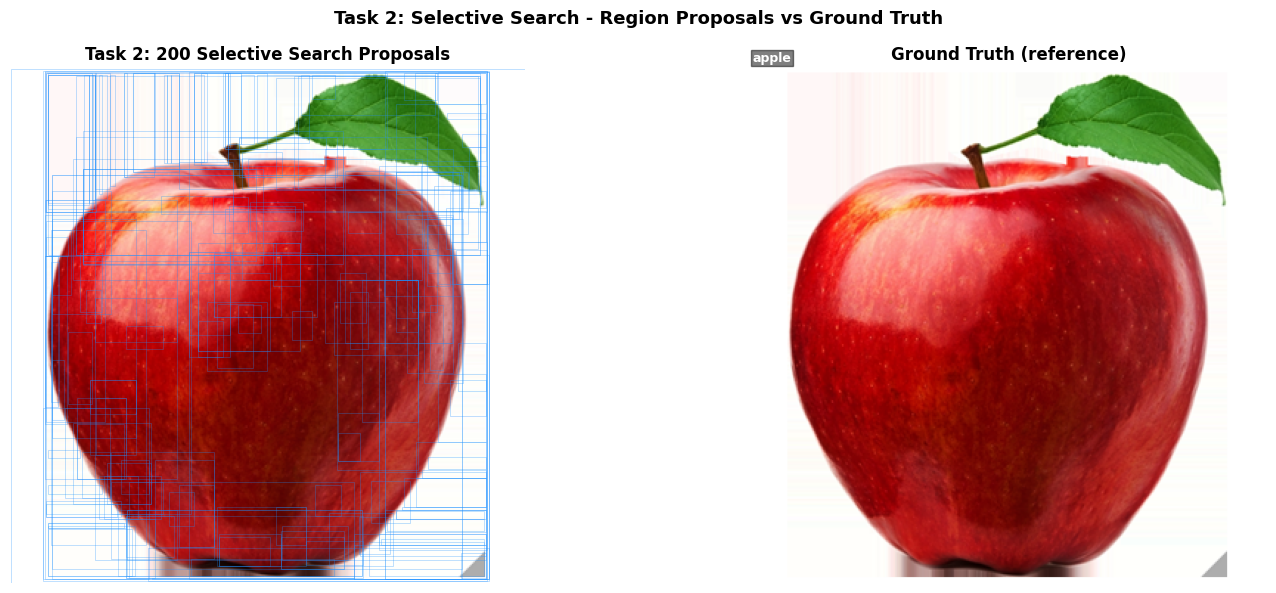

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL T2.2 - Visualise the 200 region proposals
# Blue boxes = Selective Search proposals
# Red boxes  = actual ground truth (for reference)
# ─────────────────────────────────────────────────────────────────────────────
task_gt_boxes, _, _ = parse_voc_xml(TASK_XML_PATH)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: 200 Selective Search proposals
axes[0].imshow(task_img_rgb)
for x, y, w, h in proposals_200:
    rect = patches.Rectangle((x, y), w, h,
                               linewidth=0.5, edgecolor='dodgerblue',
                               facecolor='none', alpha=0.4)
    axes[0].add_patch(rect)
axes[0].set_title('Task 2: 200 Selective Search Proposals', fontweight='bold')
axes[0].axis('off')

# Right: ground truth for comparison
axes[1].imshow(task_img_rgb)
for b in task_gt_boxes:
    color = [c/255 for c in CLASS_COLORS.get(b['class_name'], (180,180,180))]
    rect  = patches.Rectangle((b['xmin'], b['ymin']),
                                b['xmax']-b['xmin'], b['ymax']-b['ymin'],
                                linewidth=2.5, edgecolor=color, facecolor='none')
    axes[1].add_patch(rect)
    axes[1].text(b['xmin'], b['ymin']-5, b['class_name'],
                 color='white', fontsize=9, fontweight='bold',
                 bbox=dict(facecolor='black', alpha=0.5, pad=1))
axes[1].set_title('Ground Truth (reference)', fontweight='bold')
axes[1].axis('off')

plt.suptitle('Task 2: Selective Search - Region Proposals vs Ground Truth',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** The left panel shows 200 candidate regions of varying sizes and aspect ratios covering the image densely. Selective Search does not know what a fruit looks like - it proposes regions wherever pixel-level boundaries suggest an object *might* be. The right panel shows the actual ground truth for comparison. Observe that the ground-truth boxes are somewhere within the sea of proposals, which is the intended behaviour: coverage matters more than precision at this stage. R-CNN then classifies each of these 200 crops independently, which is the bottleneck we measure next.

## **Task 3 - R-CNN Bottleneck: 100 Independent CNN Passes**


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL T3.1 - Load ResNet18 with FC head removed
#
# ResNet18 ends with:  conv layers → avgpool → fc (classifier)
# We replace fc with Identity() so the model outputs a 512-d feature vector.
# ─────────────────────────────────────────────────────────────────────────────
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet18.fc = torch.nn.Identity()   # Remove classifier → outputs 512-d vector
resnet18     = resnet18.to(DEVICE)
resnet18.eval()

# Quick sanity check
with torch.no_grad():
    dummy = torch.zeros(1, 3, 224, 224).to(DEVICE)
    out   = resnet18(dummy)
print(f"ResNet18 output shape: {list(out.shape)}  (512-d feature vector per crop)")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\hp/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:08<00:00, 5.27MB/s]


ResNet18 output shape: [1, 512]  (512-d feature vector per crop)


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL T3.2 - R-CNN loop: crop → resize → CNN × 100
# We time the entire loop to quantify the bottleneck.
# ─────────────────────────────────────────────────────────────────────────────
rcnn_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

rcnn_features = []
print(f"Starting R-CNN loop on {len(proposals_100)} proposals...")

rcnn_start = time.time()

with torch.no_grad():
    for x, y, w, h in proposals_100:
        # Clamp to image boundaries (Selective Search can overshoot)
        x1 = max(0, x);          y1 = max(0, y)
        x2 = min(W_img, x + w);  y2 = min(H_img, y + h)
        if x2 <= x1 or y2 <= y1:
            continue

        # Step 1 - Crop region from original image
        crop = task_img_rgb[y1:y2, x1:x2]          # H×W×3 numpy uint8

        # Step 2 - Resize to 224×224 and normalise
        crop_t = rcnn_transform(crop).unsqueeze(0).to(DEVICE)  # 1×3×224×224

        # Step 3 - Full CNN forward pass
        feat = resnet18(crop_t)                     # 1×512
        rcnn_features.append(feat.cpu())

if DEVICE == 'cuda':
    torch.cuda.synchronize()   # Wait for all GPU ops to finish before stopping the clock

rcnn_time = time.time() - rcnn_start

print('=' * 58)
print(' Task 3 - R-CNN Timing Results '.center(58, '='))
print('=' * 58)
print(f'  Proposals processed  : {len(rcnn_features)}')
print(f'  Total time           : {rcnn_time:.4f} seconds')
print(f'  Time per crop        : {rcnn_time / len(rcnn_features) * 1000:.2f} ms')
print('=' * 58)

Starting R-CNN loop on 100 proposals...
============= Task 3 - R-CNN Timing Results ==============
  Proposals processed  : 100
  Total time           : 0.8420 seconds
  Time per crop        : 8.42 ms


## **Task 4 - Fast R-CNN: RoI Pooling**



In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL T4.1 - Build the spatial feature extractor (ResNet18 without avgpool+fc)
#
# torchvision ResNet18 children order:
#   [0] conv1  [1] bn1    [2] relu   [3] maxpool
#   [4] layer1 [5] layer2 [6] layer3 [7] layer4
#   [8] avgpool [9] fc
# We keep [0..7] - all conv layers - and discard avgpool + fc.
# Output: spatial feature map (B × 512 × H/32 × W/32)
# ─────────────────────────────────────────────────────────────────────────────
resnet18_full    = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
feature_extractor = torch.nn.Sequential(*list(resnet18_full.children())[:-2])
feature_extractor = feature_extractor.to(DEVICE)
feature_extractor.eval()

# Measure the actual stride using the task image dimensions
to_tensor = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
img_tensor = to_tensor(task_img_rgb).unsqueeze(0).to(DEVICE)  # 1×3×H×W

with torch.no_grad():
    test_fmap = feature_extractor(img_tensor)

stride_h = H_img / test_fmap.shape[2]
stride_w = W_img / test_fmap.shape[3]
spatial_scale = 1.0 / stride_w    # typically 1/32

print(f"Image tensor  : {list(img_tensor.shape)}")
print(f"Feature map   : {list(test_fmap.shape)}")
print(f"Stride (H/W)  : {stride_h:.1f} / {stride_w:.1f}")
print(f"Spatial scale : {spatial_scale:.6f}  (= 1/{int(round(stride_w))}x)")

Image tensor  : [1, 3, 349, 349]
Feature map   : [1, 512, 11, 11]
Stride (H/W)  : 31.7 / 31.7
Spatial scale : 0.031519  (= 1/32x)


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL T4.2 - Fast R-CNN: 1 CNN pass + RoI Pooling on 100 proposals
#
# torchvision.ops.roi_pool expects boxes as a Tensor of shape (N, 5)
# where each row = [batch_index, x1, y1, x2, y2]  (batch_index = 0 here)
# ─────────────────────────────────────────────────────────────────────────────
# Build RoI tensor from Selective Search proposals (convert x,y,w,h → x1,y1,x2,y2)
roi_list = []
for x, y, w, h in proposals_100:
    x1 = max(0.0, float(x))
    y1 = max(0.0, float(y))
    x2 = float(x + w)
    y2 = float(y + h)
    roi_list.append([0.0, x1, y1, x2, y2])   # batch_idx = 0

roi_tensor = torch.tensor(roi_list, dtype=torch.float32).to(DEVICE)

# Output size for RoI Pooling (fixed regardless of proposal size)
roi_output_size = (test_fmap.shape[2], test_fmap.shape[3])   # e.g. (9, 10)

print(f"RoI tensor shape : {list(roi_tensor.shape)}")
print(f"RoI output size  : {roi_output_size}")
print()
print("Starting Fast R-CNN timing...")

fast_start = time.time()

with torch.no_grad():
    # ── Step 1: Single CNN pass over the full image ──
    feature_map = feature_extractor(img_tensor)      # 1 × 512 × H/32 × W/32

    # ── Step 2: RoI Pooling - extract fixed-size regions from shared feature map ──
    pooled = roi_pool(
        input         = feature_map,
        boxes         = roi_tensor,
        output_size   = roi_output_size,
        spatial_scale = spatial_scale
    )

if DEVICE == 'cuda':
    torch.cuda.synchronize()

fast_time = time.time() - fast_start

speedup = rcnn_time / fast_time if fast_time > 0 else float('inf')

print('=' * 62)
print(' Task 4 - Fast R-CNN vs R-CNN Timing Comparison '.center(62, '='))
print('=' * 62)
print(f'  Feature map shape        : {list(feature_map.shape)}')
print(f'  Pooled features shape    : {list(pooled.shape)}')
print()
print(f'  R-CNN    (Task 3)        : {rcnn_time:.4f}s  ({rcnn_time/len(rcnn_features)*1000:.2f} ms/crop)')
print(f'  Fast R-CNN (1 pass+pool) : {fast_time:.4f}s')
print(f'  Speedup                  : {speedup:.1f}x faster')
print('=' * 62)

RoI tensor shape : [100, 5]
RoI output size  : (11, 11)

Starting Fast R-CNN timing...
======= Task 4 - Fast R-CNN vs R-CNN Timing Comparison =======
  Feature map shape        : [1, 512, 11, 11]
  Pooled features shape    : [100, 512, 11, 11]

  R-CNN    (Task 3)        : 0.8420s  (8.42 ms/crop)
  Fast R-CNN (1 pass+pool) : 0.0903s
  Speedup                  : 9.3x faster


In the R-CNN approach (Task 3), the full ResNet18 network — including all convolution layers, batch normalization, and ReLU activations — is run separately for each of the 100 region proposals. Since many of these proposals overlap significantly, the same parts of the image are processed again and again. In simple terms, the network ends up recomputing very similar features multiple times, which is highly inefficient.

Fast R-CNN solves this problem by recognizing an important property of convolution: it works locally on the image. Instead of running the network on each region proposal, it runs the convolutional backbone just once on the entire image. This produces a shared feature map where every region’s information is already available.

Then, using RoI Pooling, Fast R-CNN extracts the relevant portions for each proposal directly from this shared feature map. This step is very lightweight compared to running the full network.

As a result, instead of performing 100 full forward passes, Fast R-CNN performs 1 forward pass + 100 inexpensive pooling operations, which leads to a significant improvement in speed.

## **Task 5 - Faster R-CNN**

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL T5.1 - Load pre-trained Faster R-CNN (COCO weights)
# ─────────────────────────────────────────────────────────────────────────────
faster_rcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
)
faster_rcnn = faster_rcnn.to(DEVICE)
faster_rcnn.eval()
print("Faster R-CNN (COCO pre-trained) loaded.")

# COCO class names - fruits are present: apple=53, banana=52, orange=55
COCO_NAMES = [
    '__background__','person','bicycle','car','motorcycle','airplane','bus',
    'train','truck','boat','traffic light','fire hydrant','N/A','stop sign',
    'parking meter','bench','bird','cat','dog','horse','sheep','cow','elephant',
    'bear','zebra','giraffe','N/A','backpack','umbrella','N/A','N/A','handbag',
    'tie','suitcase','frisbee','skis','snowboard','sports ball','kite',
    'baseball bat','baseball glove','skateboard','surfboard','tennis racket',
    'bottle','N/A','wine glass','cup','fork','knife','spoon','bowl','banana',
    'apple','sandwich','orange','broccoli','carrot','hot dog','pizza','donut',
    'cake','chair','couch','potted plant','bed','N/A','dining table','N/A',
    'N/A','toilet','N/A','tv','laptop','mouse','remote','keyboard','cell phone',
    'microwave','oven','toaster','sink','refrigerator','N/A','book','clock',
    'vase','scissors','teddy bear','hair drier','toothbrush'
]
print(f"COCO classes: {len(COCO_NAMES)} total")
fruit_ids = {i: n for i, n in enumerate(COCO_NAMES) if n in ('apple','banana','orange')}
print(f"Fruit class IDs in COCO: {fruit_ids}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\hp/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:29<00:00, 5.76MB/s] 


Faster R-CNN (COCO pre-trained) loaded.
COCO classes: 91 total
Fruit class IDs in COCO: {52: 'banana', 53: 'apple', 55: 'orange'}


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL T5.2 - Run inference and filter predictions (confidence >= 0.80)
#
# Detection models expect list of float tensors [C, H, W] with values in [0,1]
# ─────────────────────────────────────────────────────────────────────────────
img_tensor_det = T.ToTensor()(task_img_rgb).to(DEVICE)   # no normalisation for detection models

with torch.no_grad():
    raw_preds = faster_rcnn([img_tensor_det])

pred = raw_preds[0]
print(f"Raw predictions : {len(pred['boxes'])} boxes")


def filter_predictions(pred, threshold=0.80):
    """Keep only predictions with confidence score >= threshold."""
    keep = pred['scores'] >= threshold
    return {
        'boxes' : pred['boxes'][keep].cpu().numpy(),
        'labels': pred['labels'][keep].cpu().numpy(),
        'scores': pred['scores'][keep].cpu().numpy(),
    }


filtered = filter_predictions(pred, threshold=0.80)
print(f"After filtering (score >= 0.80): {len(filtered['boxes'])} boxes")
for box, lbl, score in zip(filtered['boxes'], filtered['labels'], filtered['scores']):
    name = COCO_NAMES[lbl] if lbl < len(COCO_NAMES) else f'cls_{lbl}'
    print(f"  {name:12s}  score={score:.3f}  box={box.round(1)}")

Raw predictions : 1 boxes
After filtering (score >= 0.80): 1 boxes
  apple         score=0.993  box=[ 30.4  53.7 313.4 342. ]


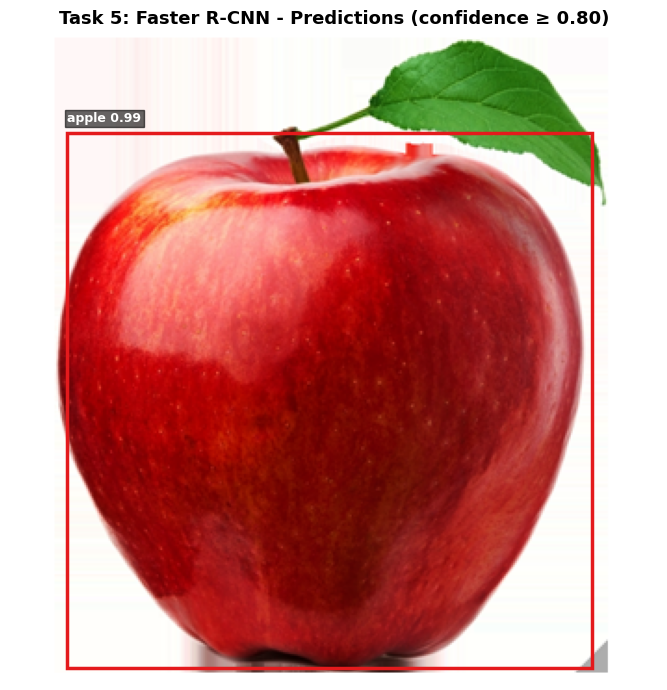

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL T5.3 - Visualise filtered Faster R-CNN predictions
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(task_img_rgb)

colors = plt.cm.Set1(np.linspace(0, 0.9, max(len(filtered['boxes']), 1)))
for i, (box, lbl, score) in enumerate(zip(
        filtered['boxes'], filtered['labels'], filtered['scores'])):
    x1, y1, x2, y2 = box
    name  = COCO_NAMES[lbl] if lbl < len(COCO_NAMES) else f'cls_{lbl}'
    color = colors[i % len(colors)]
    rect  = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                linewidth=2.5, edgecolor=color, facecolor='none')
    ax.add_patch(rect)
    ax.text(x1, y1-6, f"{name} {score:.2f}",
            color='white', fontsize=9, fontweight='bold',
            bbox=dict(facecolor='black', alpha=0.6, pad=1.5))

ax.set_title('Task 5: Faster R-CNN - Predictions (confidence ≥ 0.80)',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## **Task 5 - Conceptual Analysis**

**How does the RPN eliminate the need for Selective Search?**

Selective Search is a hand-crafted, CPU-based method that uses basic image features like color and texture to generate region proposals. It doesn’t learn from data and works independently of the neural network, so its proposals aren’t optimized for the detection task.

The Region Proposal Network (RPN) replaces this with a learnable approach. It runs on top of the backbone’s shared feature map and evaluates anchor boxes at each location. For each anchor, it predicts:

An objectness score (whether an object is present)
Bounding box adjustments (to better fit the object)

Since the RPN is part of the network, the entire pipeline is trained end-to-end, allowing it to generate more relevant proposals. It also runs on the GPU and reuses computed features, making it much faster than Selective Search.

## **Task 6 - Non-Maximum Suppression (NMS)**

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL T6.1 - Custom NMS using compute_iou() from Task 1
#
# Input:
#   boxes         : list of [xmin, ymin, xmax, ymax]
#   scores        : list of float confidence scores (same order)
#   iou_threshold : suppress if IoU > this value
# Output:
#   List of indices of surviving boxes
# ─────────────────────────────────────────────────────────────────────────────
def nms(boxes, scores, iou_threshold=0.5):
    """
    Custom Non-Maximum Suppression.
    Uses compute_iou() from Task 1 - no library calls.
    """
    if len(boxes) == 0:
        return []

    # Step 1 - Sort indices by score descending
    order = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)

    keep      = []
    remaining = list(order)

    while remaining:
        # Step 2 - Pick highest-scoring remaining box
        best = remaining.pop(0)
        keep.append(best)

        # Steps 3+4 - Suppress boxes that overlap too much with 'best'
        to_remove = []
        for idx in remaining:
            if compute_iou(boxes[best], boxes[idx]) > iou_threshold:
                to_remove.append(idx)

        remaining = [i for i in remaining if i not in to_remove]

    return keep

print("Custom NMS defined.")

Custom NMS defined.


Boxes before NMS (score >= 0.20) : 1
Boxes after  NMS (threshold=0.5) : 1


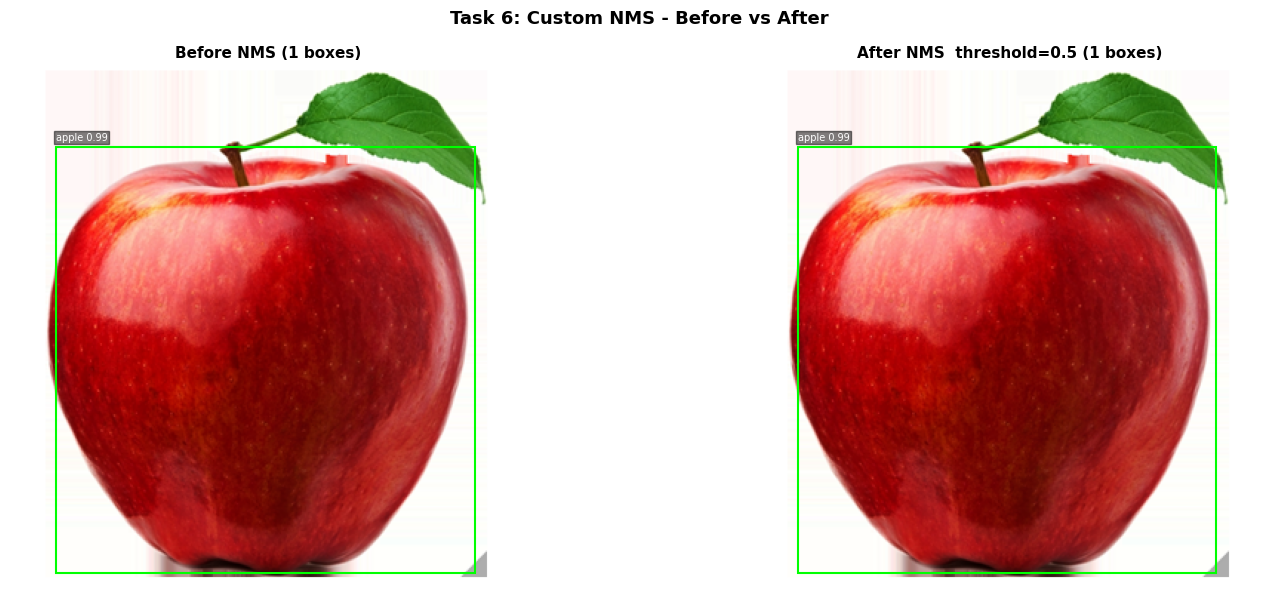

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL T6.2 - Apply NMS to Faster R-CNN raw predictions and compare
# We use a loose pre-filter (score >= 0.20) to have enough boxes to suppress.
# ─────────────────────────────────────────────────────────────────────────────
NMS_THRESHOLD = 0.50

# Pre-filter to keep scores >= 0.20
all_boxes  = pred['boxes'].cpu().numpy().tolist()
all_scores = pred['scores'].cpu().numpy().tolist()
all_labels = pred['labels'].cpu().numpy().tolist()

pre_idx   = [i for i, s in enumerate(all_scores) if s >= 0.20]
pre_boxes  = [all_boxes[i]  for i in pre_idx]
pre_scores = [all_scores[i] for i in pre_idx]
pre_labels = [all_labels[i] for i in pre_idx]

print(f"Boxes before NMS (score >= 0.20) : {len(pre_boxes)}")

kept      = nms(pre_boxes, pre_scores, iou_threshold=NMS_THRESHOLD)
nms_boxes  = [pre_boxes[i]  for i in kept]
nms_scores = [pre_scores[i] for i in kept]
nms_labels = [pre_labels[i] for i in kept]

print(f"Boxes after  NMS (threshold={NMS_THRESHOLD}) : {len(nms_boxes)}")

# ── Side-by-side visualisation ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, title, bxs, scrs, lbls in [
    (axes[0], f'Before NMS ({len(pre_boxes)} boxes)', pre_boxes, pre_scores, pre_labels),
    (axes[1], f'After NMS  threshold={NMS_THRESHOLD} ({len(nms_boxes)} boxes)',
              nms_boxes, nms_scores, nms_labels),
]:
    ax.imshow(task_img_rgb)
    for box, score, lbl in zip(bxs, scrs, lbls):
        x1, y1, x2, y2 = box
        name = COCO_NAMES[lbl] if lbl < len(COCO_NAMES) else f'cls_{lbl}'
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=1.5, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1-4, f"{name} {score:.2f}",
                color='white', fontsize=7,
                bbox=dict(facecolor='black', alpha=0.5, pad=1))
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.axis('off')

plt.suptitle('Task 6: Custom NMS - Before vs After', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## **Task 6 - Conceptual Analysis**

The IoU threshold controls how aggressively Non-Max Suppression (NMS) removes overlapping boxes.

High threshold (e.g., 0.9):
NMS is lenient — only very similar (heavily overlapping) boxes are removed.
This helps in dense scenes (like a pile of apples), where neighboring objects naturally overlap. However, it may leave duplicate boxes for the same object.
Low threshold (e.g., 0.1):
NMS is aggressive — even slightly overlapping boxes are removed.
In tightly packed scenes, this can wrongly suppress valid detections, leading to missing objects.


**Practical takeaway**<br>
Use higher IoU (0.5–0.7) for dense objects → avoids missing nearby objects
Use lower IoU (0.3–0.5) for sparse objects → removes duplicates efficiently


## **Task 7 - YOLO Fine-Tuning**

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL T7.1 - Convert Pascal VOC XML → YOLO TXT for entire dataset
#
# Creates this folder structure (required by ultralytics):
#   Lab04/
#   └── yolo_dataset/
#       ├── images/train/   ← .jpg files (copied)
#       ├── images/test/
#       ├── labels/train/   ← .txt YOLO labels (converted)
#       └── labels/test/
# ─────────────────────────────────────────────────────────────────────────────
YOLO_ROOT = os.path.join(THIS_DIR, 'yolo_dataset')

def convert_xml_to_yolo_txt(xml_path, txt_path, img_w, img_h):
    """Convert one Pascal VOC XML file to YOLO normalised TXT format."""
    boxes, _, _ = parse_voc_xml(xml_path)
    lines = []
    for b in boxes:
        cls_id = b['class_id']
        if cls_id < 0:
            continue   # Unknown class - skip
        xc = ((b['xmin'] + b['xmax']) / 2) / img_w
        yc = ((b['ymin'] + b['ymax']) / 2) / img_h
        bw = (b['xmax'] - b['xmin']) / img_w
        bh = (b['ymax'] - b['ymin']) / img_h
        # Clamp to [0, 1]
        xc = max(0.0, min(1.0, xc))
        yc = max(0.0, min(1.0, yc))
        bw = max(0.0, min(1.0, bw))
        bh = max(0.0, min(1.0, bh))
        lines.append(f"{cls_id} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")
    with open(txt_path, 'w') as f:
        f.write('\n'.join(lines))
    return len(lines)


def build_yolo_dataset(src_dir, split_name, yolo_root):
    """Copy images and generate YOLO labels for one split."""
    img_out = os.path.join(yolo_root, 'images', split_name)
    lbl_out = os.path.join(yolo_root, 'labels', split_name)
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)

    xml_files   = sorted(glob.glob(os.path.join(src_dir, '*.xml')))
    converted   = 0
    skipped     = 0

    for xml_path in xml_files:
        stem     = os.path.splitext(os.path.basename(xml_path))[0]
        jpg_path = os.path.join(src_dir, stem + '.jpg')
        if not os.path.exists(jpg_path):
            skipped += 1
            continue

        # Read image size
        img = cv2.imread(jpg_path)
        if img is None:
            skipped += 1
            continue
        h, w = img.shape[:2]

        # Copy image
        shutil.copy2(jpg_path, os.path.join(img_out, stem + '.jpg'))

        # Convert label
        txt_out_path = os.path.join(lbl_out, stem + '.txt')
        n = convert_xml_to_yolo_txt(xml_path, txt_out_path, w, h)
        if n > 0:
            converted += 1
        else:
            skipped += 1

    print(f"  [{split_name}] converted={converted}  skipped={skipped}")
    return converted


print("Building YOLO dataset...")
n_train = build_yolo_dataset(TRAIN_DIR, 'train', YOLO_ROOT)
n_test  = build_yolo_dataset(TEST_DIR,  'test',  YOLO_ROOT)
print(f"Done. Train: {n_train} images, Test: {n_test} images")
print(f"YOLO dataset root: {YOLO_ROOT}")

Building YOLO dataset...
  [train] converted=240  skipped=0
  [test] converted=60  skipped=0
Done. Train: 240 images, Test: 60 images
YOLO dataset root: c:\Users\hp\Desktop\yolo_dataset


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL T7.2 - Create data.yaml for ultralytics YOLO training
# ─────────────────────────────────────────────────────────────────────────────
data_yaml = {
    'path'  : YOLO_ROOT,
    'train' : 'images/train',
    'val'   : 'images/test',    # Using test as val (small dataset)
    'test'  : 'images/test',
    'nc'    : 3,
    'names' : CLASS_NAMES,      # ['apple', 'banana', 'orange'] - must match XML <n> tag
}

yaml_path = os.path.join(THIS_DIR, 'fruit_data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"data.yaml written to: {yaml_path}")
print()
with open(yaml_path) as f:
    print(f.read())

data.yaml written to: c:\Users\hp\Desktop\fruit_data.yaml

names:
- apple
- banana
- orange
nc: 3
path: c:\Users\hp\Desktop\yolo_dataset
test: images/test
train: images/train
val: images/test



In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL T7.3 - Fine-tune YOLOv8n on the Fruit dataset
#
# Settings tuned for RTX 2050 (4 GB VRAM):
#   imgsz=320   : images are 300×229, so 320 is a natural fit and saves VRAM
#   batch=16    : safe for 4 GB; reduce to 8 if you get CUDA out-of-memory
#   workers=2   : Windows DataLoader needs low worker count to avoid hangs
#   cache=True  : loads images into RAM - faster epochs, uses ~200 MB RAM
# ─────────────────────────────────────────────────────────────────────────────
from ultralytics import YOLO

model_yolo = YOLO('yolov8n.pt')   # Downloads ~6 MB on first run
print("YOLOv8n (COCO pre-trained) loaded.")

train_results = model_yolo.train(
    data     = yaml_path,
    epochs   = 10,
    imgsz    = 320,
    batch    = 16,
    workers  = 2,          # Critical for Windows - avoids DataLoader freeze
    cache    = True,
    device   = 0 if torch.cuda.is_available() else 'cpu',
    project  = os.path.join(THIS_DIR, 'yolo_runs'),
    name     = 'fruit_yolov8n_lab4',
    exist_ok = True,
    verbose  = True,
)
print("Training complete.")

YOLOv8n (COCO pre-trained) loaded.
New https://pypi.org/project/ultralytics/8.4.33 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.200  Python-3.10.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1650 Ti, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\hp\Desktop\fruit_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_sca

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL T7.4 - Evaluate fine-tuned model: mAP@50 and mAP@50-95
# ─────────────────────────────────────────────────────────────────────────────
best_weights    = os.path.join(THIS_DIR, 'yolo_runs', 'fruit_yolov8n_lab4', 'weights', 'best.pt')
model_finetuned = YOLO(best_weights)

val_results = model_finetuned.val(
    data   = yaml_path,
    split  = 'test',
    imgsz  = 320,
    device = 0 if torch.cuda.is_available() else 'cpu',
)

map50    = val_results.box.map50
map5095  = val_results.box.map
prec     = val_results.box.mp
rec      = val_results.box.mr

print('\n' + '=' * 58)
print(' YOLOv8n Fine-tuned - Test Set Metrics '.center(58, '='))
print('=' * 58)
print(f'  mAP@50       : {map50:.4f}')
print(f'  mAP@50-95    : {map5095:.4f}')
print(f'  Precision    : {prec:.4f}')
print(f'  Recall       : {rec:.4f}')
print('=' * 58)

Ultralytics 8.3.200  Python-3.10.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1650 Ti, 4096MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.20.0 ms, read: 60.448.5 MB/s, size: 63.1 KB)
val: Scanning C:\Users\hp\Desktop\yolo_dataset\labels\test.cache... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 57.4Kit/s 0.0s
val: C:\Users\hp\Desktop\yolo_dataset\images\test\banana_87.jpg: 3 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 0.7it/s 6.1s0.9ss
                   all         60        114      0.829      0.774      0.828      0.606
                 apple         24         35      0.845      0.779      0.833      0.654
                banana         22         37      0.727      0.784      0.774      0.508
                orange         22         42      0.914      0.759      0.878      0.655
Speed: 1.2ms preproce

Running inference on 3 test images...


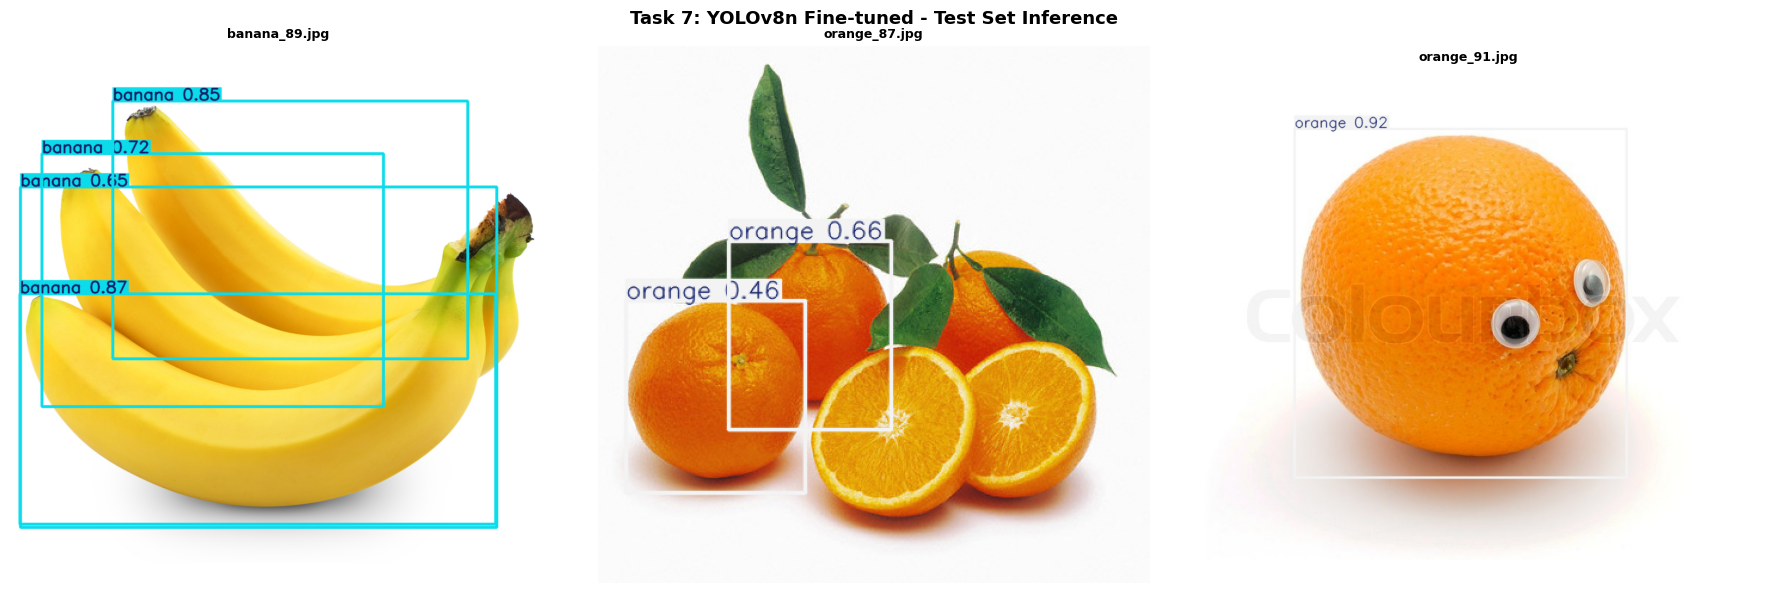

In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL T7.5 - Run inference on 3 test images with fine-tuned YOLO
# ─────────────────────────────────────────────────────────────────────────────
test_imgs = sorted(glob.glob(os.path.join(YOLO_ROOT, 'images', 'test', '*.jpg')))
sample_3  = random.sample(test_imgs, min(3, len(test_imgs)))
print(f"Running inference on {len(sample_3)} test images...")

fig, axes = plt.subplots(1, len(sample_3), figsize=(6 * len(sample_3), 6))
if len(sample_3) == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample_3):
    result     = model_finetuned(img_path, conf=0.30, verbose=False)[0]
    result_rgb = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
    ax.imshow(result_rgb)
    ax.set_title(os.path.basename(img_path), fontsize=9, fontweight='bold')
    ax.axis('off')

plt.suptitle('Task 7: YOLOv8n Fine-tuned - Test Set Inference',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL T7.6 - Inference time benchmark across all 3 model variants
# Average over N_RUNS passes on the same image for stable measurements.
# ─────────────────────────────────────────────────────────────────────────────
BENCH_IMG   = sample_3[0]
BENCH_TENSOR = T.ToTensor()(cv2.cvtColor(
    cv2.imread(BENCH_IMG), cv2.COLOR_BGR2RGB)).to(DEVICE)
N_RUNS = 10

def time_model(fn, n=N_RUNS):
    fn()   # warm-up
    if DEVICE == 'cuda': torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(n): fn()
    if DEVICE == 'cuda': torch.cuda.synchronize()
    return (time.time() - t0) / n * 1000   # ms

# Faster R-CNN
def run_frcnn():
    with torch.no_grad(): faster_rcnn([BENCH_TENSOR])
frcnn_ms = time_model(run_frcnn)

# YOLO pre-trained (reload original weights)
yolo_pre = YOLO('yolov8n.pt')
def run_yolo_pre(): yolo_pre(BENCH_IMG, verbose=False)
ypre_ms = time_model(run_yolo_pre)

# YOLO fine-tuned
def run_yolo_ft(): model_finetuned(BENCH_IMG, verbose=False)
yft_ms = time_model(run_yolo_ft)

print(f"Faster R-CNN     : {frcnn_ms:.1f} ms/image")
print(f"YOLO pre-trained : {ypre_ms:.1f} ms/image")
print(f"YOLO fine-tuned  : {yft_ms:.1f} ms/image")

Faster R-CNN     : 219.3 ms/image
YOLO pre-trained : 45.5 ms/image
YOLO fine-tuned  : 39.4 ms/image


In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL T7.7 - Final Comparison Table
# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '═' * 85)
print(' Task 7 - Model Comparison Table '.center(85, '═'))
print('═' * 85)
print(f"{'Model':<30} {'Inference (ms)':<18} {'Precision':<14} {'Recall':<12} {'mAP@50'}")
print('─' * 85)
print(f"{'Faster R-CNN (pre-trained)':<30} {frcnn_ms:<18.1f} {'N/A*':<14} {'N/A*':<12} {'N/A*'}")
print(f"{'YOLOv8n (pre-trained)':<30} {ypre_ms:<18.1f} {'N/A*':<14} {'N/A*':<12} {'N/A*'}")
print(f"{'YOLOv8n (fine-tuned)':<30} {yft_ms:<18.1f} {prec:<14.4f} {rec:<12.4f} {map50:.4f}")
print('═' * 85)
print(f"  mAP@50-95 (fine-tuned): {map5095:.4f}")
print()
print("  * Faster R-CNN and YOLO pre-trained were not fine-tuned on the Fruit dataset.")
print("    Precision/Recall/mAP are only meaningful after domain-specific training.")
print('═' * 85)


═════════════════════════════════════════════════════════════════════════════════════
══════════════════════════ Task 7 - Model Comparison Table ══════════════════════════
═════════════════════════════════════════════════════════════════════════════════════
Model                          Inference (ms)     Precision      Recall       mAP@50
─────────────────────────────────────────────────────────────────────────────────────
Faster R-CNN (pre-trained)     219.3              N/A*           N/A*         N/A*
YOLOv8n (pre-trained)          45.5               N/A*           N/A*         N/A*
YOLOv8n (fine-tuned)           39.4               0.8287         0.7738       0.8283
═════════════════════════════════════════════════════════════════════════════════════
  mAP@50-95 (fine-tuned): 0.6057

  * Faster R-CNN and YOLO pre-trained were not fine-tuned on the Fruit dataset.
    Precision/Recall/mAP are only meaningful after domain-specific training.
══════════════════════════════════════════

**Observation (Task 7):**  
Faster R-CNN: Most accurate but slowest due to its two-stage design.<br>
YOLOv8n (pre-trained): Fastest, but accuracy depends on how well the dataset matches COCO classes.<br>
YOLOv8n (fine-tuned): Best overall for this task — combines good speed with highest accuracy after adapting to the dataset.<br>

---
## **Summary**

| Task | What Was Built | Key Takeaway |
|------|---------------|-------------|
| Prep | VOC XML parser + GT visualisation | Non-standard `<n>` class tag successfully handled |
| T1 | IoU from scratch | Foundation for NMS and mAP evaluation |
| T2 | Selective Search 200 proposals | CPU-bound, ~2000 redundant regions per image |
| T3 | R-CNN bottleneck (timed) | 100 CNN passes - expensive and redundant |
| T4 | Fast R-CNN RoI Pooling (timed) | 1 CNN pass eliminates N redundant computations |
| T5 | Faster R-CNN inference | RPN learns proposals end-to-end on the GPU |
| T6 | Custom NMS | Greedy IoU suppression removes duplicate detections |
| T7 | YOLOv8n fine-tuned | Single-pass regression, best speed+accuracy balance |

---
